# Trajectory Plots
This notebook takes a list of dictionaries with folder names and tags, then generates a trajectory plot with lines for all replicates (i.e. not averaged across replicates).

## Set up

In [1]:
# Dictionary of folder paths and relevant tags
superfolder_paths = [
    "experiments/20260118_farm_novar/model_name_Qwen3-14B_prompt_summhist",
    "experiments/20260118_farm_novar/model_name_Qwen3-32B_prompt_summhist",
    "experiments/20260120_ab_novar/model_name_Qwen3-14B_prompt_summhist",
    "experiments/20260120_ab_novar/model_name_Qwen3-32B_prompt_summhist",
]

In [2]:
import os
os.chdir("../..")

### Function: map_sf_path_to_keys

This function takes a list of folder paths and maps each path to a dictionary containing the following keys:

- **domain**: Identifies the domain based on the folder path. If the path contains "farm", it is categorized as "Farm". If it contains "abandit" or "ab", it is categorized as "Bandit". Otherwise, it is labeled as "Unknown".
- **model**: Extracts the model name from the folder path. The model name is expected to follow the pattern `model_name_[model]`.
- **variance**: Determines the variance level based on the folder path. If the path contains "4sd_var", it is categorized as "High". If it contains "2sd_var", it is categorized as "Low". Otherwise, it is labeled as "No".
- **superfolder_path**: The original folder path is included for reference.

The function returns a pandas DataFrame with columns corresponding to these keys.

In [3]:
import re
import pandas as pd

def map_sf_paths_to_keys(folder_paths):
    data = []

    for folder_path in folder_paths:
        # Determine domain
        if "farm" in folder_path:
            domain = "Farm"
        elif "abandit" in folder_path or "ab" in folder_path:
            domain = "Bandit"
        else:
            domain = "Unknown"

        # Extract model
        model_match = re.search(r"model_name_([a-zA-Z0-9\-]+)[_/]", folder_path)
        model = model_match.group(1) if model_match else "Unknown"

        # Determine variance
        if "4sd_var" in folder_path:
            variance = "High"
        elif "2sd_var" in folder_path:
            variance = "Low"
        else:
            variance = "No"

        data.append({
            "domain": domain,
            "model": model,
            "variance": variance,
            "superfolder_path": folder_path
        })

    return pd.DataFrame(data)


## Data Loading

In [4]:
superdfs_tags_df = map_sf_paths_to_keys(superfolder_paths)

In [5]:
superdfs_tags_df

,domain,model,variance,superfolder_path
0,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...
1,Farm,Qwen3-32B,No,experiments/20260118_farm_novar/model_name_Qwe...
2,Bandit,Qwen3-14B,No,experiments/20260120_ab_novar/model_name_Qwen3...
3,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...


In [6]:
# Now we shift to creating a new Dataframe for all the semantic variation folders, including the scale and nomenclature tags

# look for subfolders within each superfolder.
# Tag each of them based on the nomenclature and scale they contain (see below)
# Create a new dataframe where each row is the path to a semantic variation folder (subfolder of the superfolder)
# Each row will also contain the columns from superdfs_tags_df for the corresponding superfolder as well as new columns for nomenclature and scale

nomenclature_list = [
    'alphanumeric',
    'ordinal_helpful',
    'ordinal_mislead',
    'sem_rel_helpful',
    'sem_rel_mislead',
    'sent_helpful',
    'sent_mislead',
]

scale_list = [
    'high_neg_scale',
    'low_neg_scale',
    'low_scale',
    'high_scale'
]



In [7]:
# Iterate through each superfolder path and find subfolders
semantic_variation_data = []

for _, row in superdfs_tags_df.iterrows():
    superfolder_path = row['superfolder_path']
    for nomenclature in nomenclature_list:
        for scale in scale_list:
            # Construct the semantic variation folder path
            semantic_folder = f"{superfolder_path}/{nomenclature}_{scale}"
            semantic_variation_data.append({
                **row.to_dict(),
                "nomenclature": nomenclature,
                "scale": scale,
                "semantic_folder": semantic_folder
            })

# Create a new DataFrame for semantic variation folders
semantic_variation_df = pd.DataFrame(semantic_variation_data)
semantic_variation_df

,domain,model,variance,superfolder_path,nomenclature,scale,semantic_folder
0,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...
1,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,low_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...
2,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,low_scale,experiments/20260118_farm_novar/model_name_Qwe...
3,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_scale,experiments/20260118_farm_novar/model_name_Qwe...
4,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,ordinal_helpful,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...
...,...,...,...,...,...,...,...
107,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_helpful,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...
108,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_neg_scale,experiments/20260120_ab_novar/model_name_Qwen3...
109,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,low_neg_scale,experiments/20260120_ab_novar/model_name_Qwen3...
110,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,low_scale,experiments/20260120_ab_novar/model_name_Qwen3...


In [8]:
# Now we will create a new dataframe with rows for each of the replicates, including the shuffle number tag

# Go to the ./shuffles subfolder of each semantic variation folder, 
# find the shuffles/shuffle_i subfolders and find the most recent jsonl with at least 10 rows
# Create a new dataframe with all columns from the semantic variation df but also with shuffle number (i in the case of shuffle_i)

In [9]:
# Iterate through each semantic variation folder and find shuffle subfolders
import os
from glob import glob

replicate_data = []

for _, row in semantic_variation_df.iterrows():
    semantic_folder = row['semantic_folder']
    shuffle_folder = f"{semantic_folder}/shuffles"

    if os.path.exists(shuffle_folder):
        # Find all shuffle subfolders
        shuffle_paths = glob(f"{shuffle_folder}/shuffle_*")

        for shuffle_path in shuffle_paths:
            # Find all jsonl files in the shuffle folder
            jsonl_files = glob(f"{shuffle_path}/*.jsonl")

            # Sort files by modification time (most recent first)
            jsonl_files.sort(key=os.path.getmtime, reverse=True)

            for jsonl_file in jsonl_files:
                try:
                    # Read the jsonl file
                    df = pd.read_json(jsonl_file, lines=True)

                    # Check if it has at least 10 rows
                    if len(df) >= 10:
                        replicate_data.append({
                            **row.to_dict(),
                            "shuffle_number": os.path.basename(shuffle_path).split("_")[-1],
                            "jsonl_file": jsonl_file
                        })
                        break  # Only take the most recent valid file
                except Exception as e:
                    continue

# Create a new DataFrame for replicates
replicate_df = pd.DataFrame(replicate_data)
replicate_df

,domain,model,variance,superfolder_path,nomenclature,scale,semantic_folder,shuffle_number,jsonl_file
0,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,3,experiments/20260118_farm_novar/model_name_Qwe...
1,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,4,experiments/20260118_farm_novar/model_name_Qwe...
2,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,5,experiments/20260118_farm_novar/model_name_Qwe...
3,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,2,experiments/20260118_farm_novar/model_name_Qwe...
4,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,7,experiments/20260118_farm_novar/model_name_Qwe...
...,...,...,...,...,...,...,...,...,...
955,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,0,experiments/20260120_ab_novar/model_name_Qwen3...
956,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,9,experiments/20260120_ab_novar/model_name_Qwen3...
957,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,8,experiments/20260120_ab_novar/model_name_Qwen3...
958,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,1,experiments/20260120_ab_novar/model_name_Qwen3...


## Eval

In [10]:
# Now, we will process the jsonl for all replicates and create new columns for the exploration count at each turn. 

def get_exploration_count_per_turn(rep_df):
    # Iterate through each row in the replicate DataFrame
    for _, row in rep_df.iterrows():
        jsonl_file = row['jsonl_file']

        try:
            # Load the JSONL file
            data = pd.read_json(jsonl_file, lines=True)

            # Initialize a set to track unique actions
            unique_actions = set()

            # Iterate through each turn in the JSONL file
            for idx, record in data.iterrows():
                action = record.get('action_taken_id')
                if action is not None:
                    unique_actions.add(action)

                # Add a new column for the exploration count at this turn
                column_name = f"exploration_count_{idx}"
                rep_df.at[row.name, column_name] = len(unique_actions)
        except Exception as e:
            print(f"Error processing file {jsonl_file}: {e}")

    return rep_df

# Example usage
replicate_df = get_exploration_count_per_turn(replicate_df)
replicate_df

,domain,model,variance,superfolder_path,nomenclature,scale,semantic_folder,shuffle_number,jsonl_file,exploration_count_0,exploration_count_1,exploration_count_2,exploration_count_3,exploration_count_4,exploration_count_5,exploration_count_6,exploration_count_7,exploration_count_8,exploration_count_9
0,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,3,experiments/20260118_farm_novar/model_name_Qwe...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
1,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,4,experiments/20260118_farm_novar/model_name_Qwe...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
2,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,5,experiments/20260118_farm_novar/model_name_Qwe...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
3,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,2,experiments/20260118_farm_novar/model_name_Qwe...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
4,Farm,Qwen3-14B,No,experiments/20260118_farm_novar/model_name_Qwe...,alphanumeric,high_neg_scale,experiments/20260118_farm_novar/model_name_Qwe...,7,experiments/20260118_farm_novar/model_name_Qwe...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,0,experiments/20260120_ab_novar/model_name_Qwen3...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
956,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,9,experiments/20260120_ab_novar/model_name_Qwen3...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
957,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,8,experiments/20260120_ab_novar/model_name_Qwen3...,1.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
958,Bandit,Qwen3-32B,No,experiments/20260120_ab_novar/model_name_Qwen3...,sent_mislead,high_scale,experiments/20260120_ab_novar/model_name_Qwen3...,1,experiments/20260120_ab_novar/model_name_Qwen3...,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


## Plotting

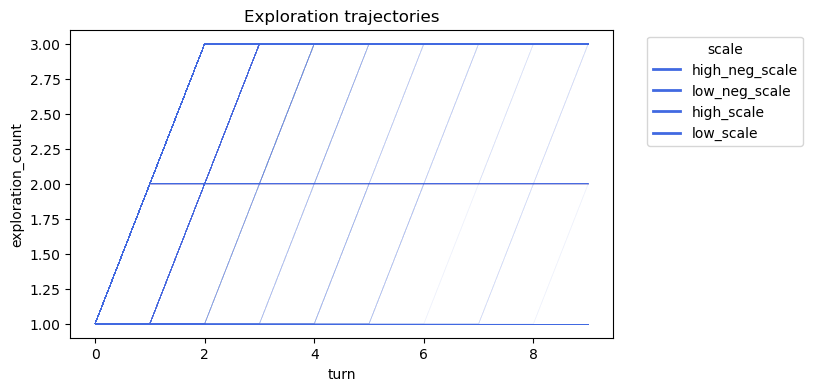

In [11]:
# First, we create the plotting code 

from src.viz.trajectory_plots import (
    plot_exploration_trajectories,
    plot_avg_turns_between_increases,
)


# replicate_df: your DataFrame
# variable: column name, e.g. 'condition'
# colour_map: e.g. {'A':'#1f77b4', 'B':'#ff7f0e'}

# Now specify the variables you want to plot along 

var_of_interest = 'scale'
var_colour_map = {
    'high_neg_scale': 'royalblue',
    'low_neg_scale': 'royalblue',
    'high_scale': 'royalblue',
    'low_scale': 'royalblue',
}

ax = plot_exploration_trajectories(replicate_df, var_of_interest, var_colour_map)

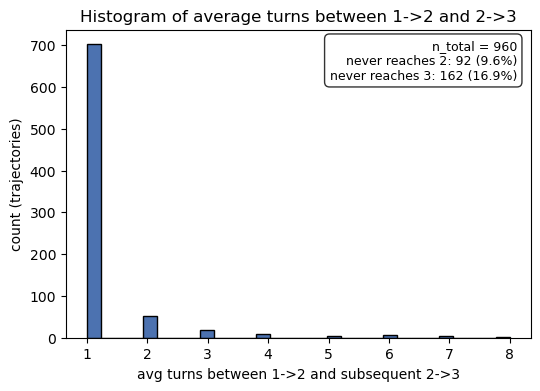

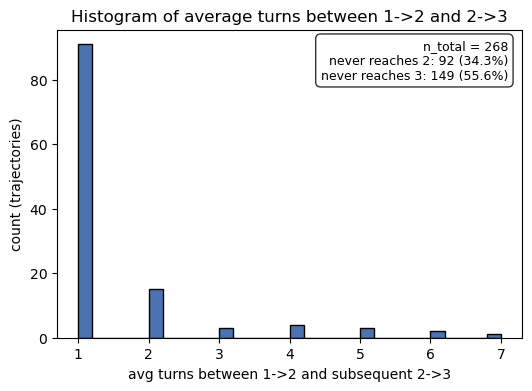

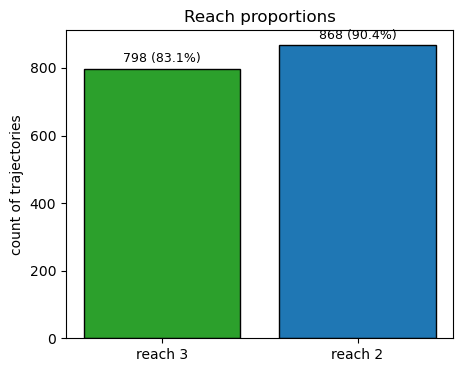

,never_reaches_2,never_reaches_3,never reaches 2,never reaches 3,avg_turns_between_12_23,counts_12_events,counts_complete_pairs
0,False,False,False,False,1.0,1,1
1,False,False,False,False,1.0,1,1
2,False,False,False,False,1.0,1,1
3,False,False,False,False,1.0,1,1
4,False,False,False,False,1.0,1,1


In [12]:
# Compute and plot histogram of average turns between increases
from src.viz.trajectory_plots import plot_avg_turns_between_increases, plot_reach_proportions, filter_exclude_first_burst
import matplotlib.pyplot as plt

ax2, results_df2 = plot_avg_turns_between_increases(replicate_df)
plt.show()

# Create filtered dataframe excluding trajectories that explored in first burst
filtered_df = filter_exclude_first_burst(replicate_df)
ax4, results_df4 = plot_avg_turns_between_increases(filtered_df)
plt.show()

# Plot reach proportions (separate plot)
ax3, results_df3 = plot_reach_proportions(replicate_df)
plt.show()

# Show the computed columns (both underscored and spaced variants)
results_df2[["never_reaches_2", "never_reaches_3", "never reaches 2", "never reaches 3", "avg_turns_between_12_23", "counts_12_events", "counts_complete_pairs"]].head()


### If time: Try to create an interactive dashboard using WAndB